### Exercício 1

In [1]:
# Instalando as bibliotecas necessárias para a execução otimizada da simulação
!pip install numba pandas matplotlib --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importando as bibliotecas necessárias

In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from numba import jit

#### Configurações para exibição de gráficos no Jupyter Notebook

In [3]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

### Função de Simulação da fila M/M/1

In [4]:
@jit(nopython=True)
def simular_esperas_mm1(n_clientes, lambd, mu):
    """
    Simula uma fila M/M/1 partindo do estado vazio (fila = 0).
    Retorna um array contendo o tempo de espera na fila de cada cliente.
    """
    esperas = np.zeros(n_clientes)
    t_chegada_atual = 0.0
    t_saida_anterior = 0.0

    for i in range(n_clientes):
        # Tempo de interchegada (Distribuição Exponencial)
        interchegada = -np.log(1.0 - random.random()) / lambd
        t_chegada_atual += interchegada

        # Tempo de serviço (Distribuição Exponencial)
        servico = -np.log(1.0 - random.random()) / mu

        # Cálculo do tempo de espera na fila
        if t_chegada_atual < t_saida_anterior:
            esperas[i] = t_saida_anterior - t_chegada_atual
            t_saida_anterior += servico
        else:
            esperas[i] = 0.0
            t_saida_anterior = t_chegada_atual + servico

    return esperas

### Implementação das heurísticas de eliminação do transiente

In [5]:
@jit(nopython=True)
def heuristica_conway(esperas):
    """
    Regra de Conway: O transiente dura até que um valor analisado
    não seja nem o maior nem o menor comparado a TODOS os valores à sua frente.
    """
    n = len(esperas)
    for i in range(n):
        val_min = esperas[i]
        val_max = esperas[i]
        for j in range(i, n):
            if esperas[j] < val_min: val_min = esperas[j]
            if esperas[j] > val_max: val_max = esperas[j]

        if esperas[i] > val_min and esperas[i] < val_max:
            return i
    return 0

@jit(nopython=True)
def heuristica_fishman(esperas, k_alvo=7):
    """
    Regra de Fishman: O estado transiente termina após a série temporal
    cruzar a linha da sua própria média global k vezes (tipicamente k=7 ou 25).
    """
    n = len(esperas)
    soma = 0.0
    for x in esperas:
        soma += x
    media_global = soma / n

    cruzes = 0
    for i in range(1, n):
        if (esperas[i] - media_global) * (esperas[i-1] - media_global) < 0:
            cruzes += 1
            if cruzes == k_alvo:
                return i
    return 0

@jit(nopython=True)
def heuristica_mser5y(esperas):
    """
    MSER-5Y: Agrupa os dados em lotes (batches) de tamanho 5 e encontra o ponto d
    que minimiza o erro padrão do estado estacionário restante.
    """
    N = len(esperas)
    k = N // 5
    if k < 4: return 0

    # Reduzindo a série original para a série de médias de lote Z_j
    Z = np.zeros(k)
    for j in range(k):
        soma_b = 0.0
        for i in range(5):
            soma_b += esperas[5 * j + i]
        Z[j] = soma_b / 5.0

    best_d = 0
    min_mser = 1e30
    limite_d = k // 2  # Restrição teórica: d* deve estar na primeira metade da série

    for d in range(limite_d):
        soma_z = 0.0
        for j in range(d, k): soma_z += Z[j]
        media_z = soma_z / (k - d)

        soma_var = 0.0
        for j in range(d, k): soma_var += (Z[j] - media_z) ** 2

        mser_val = soma_var / ((k - d) ** 2)
        if mser_val < min_mser:
            min_mser = mser_val
            best_d = d

    return best_d * 5

### Exercício 4 – Análise do Transiente com Viés Bruto

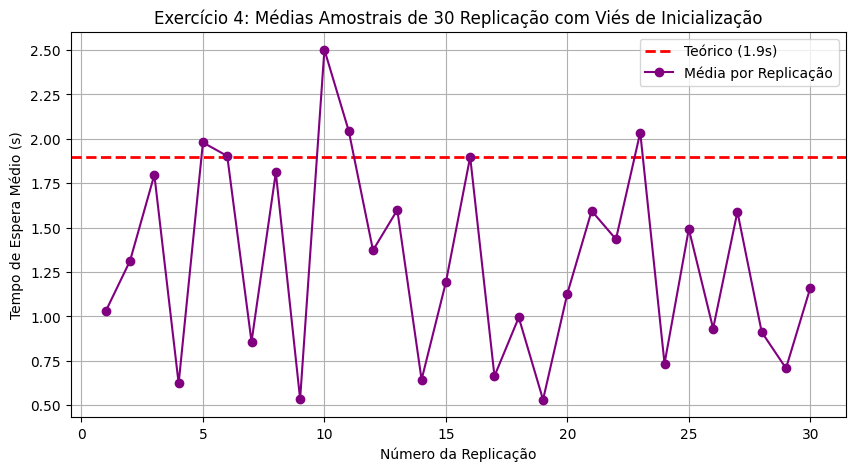

MÉDIA GLOBAL X_n: 1.3005s
VIÉS MÉDIO GLOBAL (B): -0.5995s


,Replicação (r),X_n Médio,Viés (B)
0,1,1.029692,-0.870308
1,2,1.313276,-0.586724
2,3,1.797298,-0.102702
3,4,0.622447,-1.277553
4,5,1.979442,0.079442
5,6,1.903496,0.003496
6,7,0.857330,-1.042670
7,8,1.810623,-0.089377
8,9,0.535063,-1.364937
9,10,2.501849,0.601849


In [6]:
# Parâmetros fornecidos pelo Exercício 4
lambd, mu, n, r = 9.5, 10.0, 1000, 30
val_teorico = 1.9  # E[X] calculado analiticamente

resultados_ex4 = []
for i in range(r):
    esperas = simular_esperas_mm1(n, lambd, mu)
    media_amostral = np.mean(esperas)
    bias = media_amostral - val_teorico
    resultados_ex4.append([i+1, media_amostral, bias])

df_ex4 = pd.DataFrame(resultados_ex4, columns=['Replicação (r)', 'X_n Médio', 'Viés (B)'])

# Gráfico da evolução das médias amostrais comparadas ao Valor Teórico
plt.figure()
plt.axhline(y=val_teorico, color='red', linestyle='--', linewidth=2, label=f'Teórico ({val_teorico}s)')
plt.plot(df_ex4['Replicação (r)'], df_ex4['X_n Médio'], marker='o', color='purple', label='Média por Replicação')
plt.title('Exercício 4: Médias Amostrais de 30 Replicação com Viés de Inicialização')
plt.xlabel('Número da Replicação')
plt.ylabel('Tempo de Espera Médio (s)')
plt.legend()
plt.show()

print(f"MÉDIA GLOBAL X_n: {df_ex4['X_n Médio'].mean():.4f}s")
print(f"VIÉS MÉDIO GLOBAL (B): {df_ex4['Viés (B)'].mean():.4f}s")

# Exibe a tabela nativa do Pandas no Notebook
df_ex4

### Exercício 5 – Eliminação do Transiente (Conway vs Fishman)

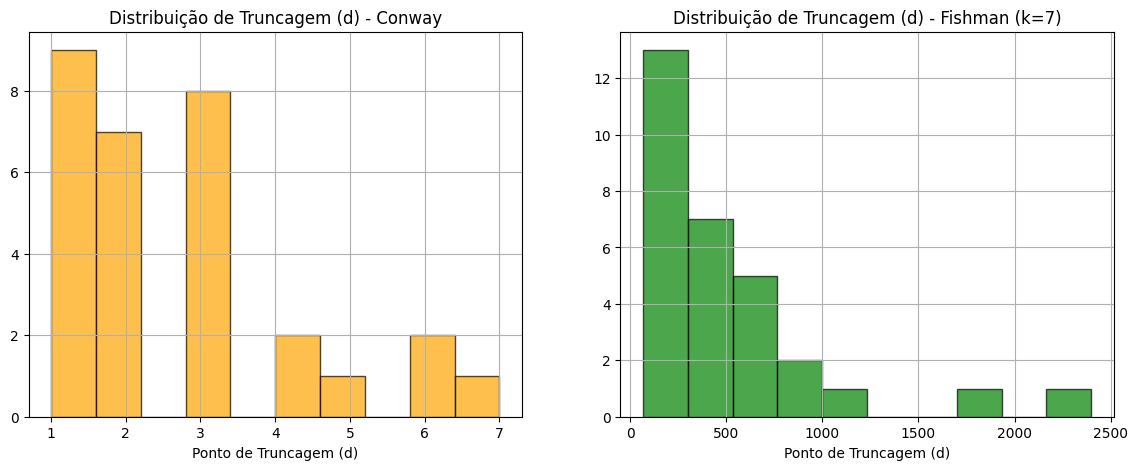

Viés Médio Conway: -0.6431s | d médio: 2.6
Viés Médio Fishman: 0.4923s | d médio: 507.9


,r,X_n (Conway),Bias (Conway),d_Conway,X_n (Fishman),Bias (Fishman),d_Fishman
0,1,1.694958,-0.205042,2,0.851776,-1.048224,661
1,2,2.457278,0.557278,2,1.039265,-0.860735,680
2,3,0.601460,-1.298540,1,0.621770,-1.278230,263
3,4,1.018856,-0.881144,3,1.338765,-0.561235,300
4,5,0.905537,-0.994463,1,4.572003,2.672003,1074
5,6,1.077373,-0.822627,2,1.291571,-0.608429,339
6,7,0.754355,-1.145645,3,0.743141,-1.156859,71
7,8,0.781359,-1.118641,1,0.801569,-1.098431,456
8,9,4.154284,2.254284,6,4.583920,2.683920,372
9,10,1.471088,-0.428912,1,1.499909,-0.400091,92


In [7]:
# Parâmetros fornecidos pelo Exercício 5
lambd, mu, n_estacionario, r = 9.5, 10.0, 1000, 30
val_teorico = 1.9

res_conway, res_fishman = [], []

for i in range(r):
    # Geramos uma sequência maior (5000) para garantir que possamos extrair
    # 1000 observações limpas a partir do ponto de corte d detectado.
    esperas_brutas = simular_esperas_mm1(5000, lambd, mu)

    # Heurística de Conway
    d_conway = heuristica_conway(esperas_brutas)
    estavel_conway = esperas_brutas[d_conway:d_conway + n_estacionario]
    media_c = np.mean(estavel_conway)
    res_conway.append([i+1, media_c, media_c - val_teorico, d_conway])

    # Heurística de Fishman (k=7)
    d_fishman = heuristica_fishman(esperas_brutas, k_alvo=7)
    estavel_fishman = esperas_brutas[d_fishman:d_fishman + n_estacionario]
    media_f = np.mean(estavel_fishman)
    res_fishman.append([i+1, media_f, media_f - val_teorico, d_fishman])

df_c = pd.DataFrame(res_conway, columns=['r', 'X_n (Conway)', 'Bias (Conway)', 'd_Conway'])
df_f = pd.DataFrame(res_fishman, columns=['r', 'X_n (Fishman)', 'Bias (Fishman)', 'd_Fishman'])

# Plotagem comparativa da distribuição dos pontos de corte (d)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(df_c['d_Conway'], bins=10, color='orange', alpha=0.7, edgecolor='black')
ax1.set_title('Distribuição de Truncagem (d) - Conway')
ax1.set_xlabel('Ponto de Truncagem (d)')

ax2.hist(df_f['d_Fishman'], bins=10, color='green', alpha=0.7, edgecolor='black')
ax2.set_title('Distribuição de Truncagem (d) - Fishman (k=7)')
ax2.set_xlabel('Ponto de Truncagem (d)')
plt.show()

print(f"Viés Médio Conway: {df_c['Bias (Conway)'].mean():.4f}s | d médio: {df_c['d_Conway'].mean():.1f}")
print(f"Viés Médio Fishman: {df_f['Bias (Fishman)'].mean():.4f}s | d médio: {df_f['d_Fishman'].mean():.1f}")

# Unificando as tabelas para facilitar a inspeção lado a lado
df_ex5 = pd.merge(df_c, df_f, on='r')
df_ex5

### Exercício 6 – Horizonte Infinito, Algoritmo MSER-5Y

In [8]:
# Parâmetros fornecidos pelo Exercício 6
lambd, mu = 9.5, 10.0
val_teorico = 1.9
gamma_alvo = 0.05  # Precisão de 5%

n_inicial = 15000  # Tamanho amostral de partida para o Horizonte Infinito
passo_incremento = 10000

while True:
    esperas = simular_esperas_mm1(n_inicial, lambd, mu)
    d_mser = heuristica_mser5y(esperas)
    dados_estacionarios = esperas[d_mser:]

    # Agrupamento em lotes para calcular a variância sem o viés da correlação temporal
    tamanho_lote = 200
    n_lotes = len(dados_estacionarios) // tamanho_lote

    if n_lotes < 15:
        n_inicial += passo_incremento
        continue

    lotes = np.array([np.mean(dados_estacionarios[i*tamanho_lote:(i+1)*tamanho_lote]) for i in range(n_lotes)])
    media_mser = np.mean(dados_estacionarios)

    # Variância da média global baseada na variância das médias de lote
    var_lotes = np.var(lotes, ddof=1) / n_lotes
    h = 1.96 * np.sqrt(var_lotes)  # Margem de erro para 95% de confiança
    precisao_atingida = h / media_mser

    # Se a regra de parada for atendida, saímos do loop dinâmico
    if precisao_atingida <= gamma_alvo:
        break
    else:
        n_inicial += passo_incremento

print("=== RESULTADOS HORIZONTE INFINITO (MSER-5Y) ===")
print(f"Total de Clientes Gerados: {n_inicial}")
print(f"Ponto de Truncagem (d): {d_mser}")
print(f"Clientes Utilizados no Estado Estacionário: {len(dados_estacionarios)}")
print(f"Média Estimada: {media_mser:.4f}s")
print(f"Intervalo de Confiança (95%): [{media_mser - h:.4f}s , {media_mser + h:.4f}s]")
print(f"Precisão Relativa Obtida: {precisao_atingida*100:.2f}% (Alvo: <= {gamma_alvo*100}%)")


=== RESULTADOS HORIZONTE INFINITO (MSER-5Y) ===
Total de Clientes Gerados: 265000
Ponto de Truncagem (d): 1440
Clientes Utilizados no Estado Estacionário: 263560
Média Estimada: 1.8392s
Intervalo de Confiança (95%): [1.7494s , 1.9291s]
Precisão Relativa Obtida: 4.88% (Alvo: <= 5.0%)


### Comparativo final das 3 heurísticas

C:\Users\hugom\AppData\Local\Temp\ipykernel_44112\2687023908.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(dados_boxplot,


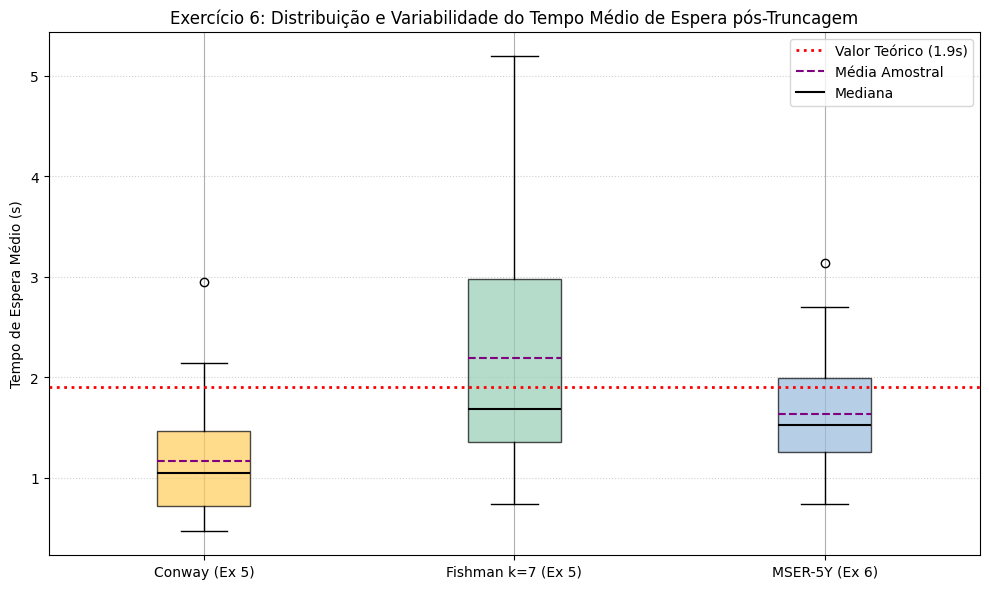

In [ ]:
lambd, mu = 9.5, 10.0
r_replicacoes = 30
n_janela_coleta = 1000

dados_conway = []
dados_fishman = []

# 1. Coleta para Conway e Fishman (Exercício 5: r=30 replicações de horizonte finito)
for _ in range(r_replicacoes):
    # Série de tamanho intermediário para garantir cruzamentos e buscas estáveis pelas heurísticas
    serie_esperas = simular_esperas_mm1(8000, lambd, mu)

    d_c = heuristica_conway(serie_esperas)
    d_f = heuristica_fishman(serie_esperas, k_alvo=7)

    # Coleta os n=1000 valores exatamente após o ponto de truncagem de cada um
    dados_conway.append(np.mean(serie_esperas[d_c : d_c + n_janela_coleta]))
    dados_fishman.append(np.mean(serie_esperas[d_f : d_f + n_janela_coleta]))

# 2. Coleta para MSER-5Y (Exercício 6: Simulação de Horizonte Infinito + Batch Means)
# Geramos uma única corrida massiva para alcançar o verdadeiro regime permanente
n_horizonte_infinito = 200000
serie_longa = simular_esperas_mm1(n_horizonte_infinito, lambd, mu)

# Encontra o d ótimo com base no horizonte infinito
d_m = heuristica_mser5y(serie_longa)
estado_estacionario_mser = serie_longa[d_m:]

# Divide o estado estacionário restante em 30 lotes idênticos (Batch Means) para o boxplot
tamanho_lote = len(estado_estacionario_mser) // r_replicacoes
dados_mser5y = [
    np.mean(estado_estacionario_mser[i * tamanho_lote : (i + 1) * tamanho_lote])
    for i in range(r_replicacoes)
]

dados_boxplot = [dados_conway, dados_fishman, dados_mser5y]
labels_heuristicas = ['Conway (Ex 5)', 'Fishman k=7 (Ex 5)', 'MSER-5Y (Ex 6)']

# 2. Configuração da figura
plt.figure(figsize=(10, 6))

# Criando o boxplot com preenchimento colorido
box = plt.boxplot(dados_boxplot,
                  labels=labels_heuristicas,
                  patch_artist=True,
                  showmeans=True,
                  meanline=True,
                  medianprops={'color': 'black', 'linewidth': 1.5},
                  meanprops={'color': 'purple', 'linestyle': '--', 'linewidth': 1.5})

# Customização de cores dos boxes
cores = ['#ffcc5c', '#96ceb4', '#99badd'] # Laranja, Verde, Azul
for patch, color in zip(box['boxes'], cores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 3. Linha do valor teórico exato (Exigência dos slides)
val_teorico = 1.9
plt.axhline(y=val_teorico, color='red', linestyle=':', linewidth=2, label=f'Valor Teórico ({val_teorico}s)')

# 4. Ajustes de eixos e títulos
plt.title('Exercício 6: Distribuição e Variabilidade do Tempo Médio de Espera pós-Truncagem')
plt.ylabel('Tempo de Espera Médio (s)')
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Legenda customizada para indicar média e mediana
plt.plot([], [], color='purple', linestyle='--', label='Média Amostral')
plt.plot([], [], color='black', label='Mediana')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()